# 🚀 LangGraph Startup Builder — 3 AI Employees in Multi-Turn Conversation

A **multi-turn LangGraph workflow** where 3 specialized AI employees **debate each other** across 3 rounds to build a satellite imagery startup plan.

| Employee | Role | Personality |
|----------|------|-------------|
| 🔴 **Startup Validator** | Ruthless CSO | Demands evidence, forces Lean Canvas, kills bad ideas |
| 🔵 **Senior Engineer** | Elite CTO | Ships MVPs, refuses over-engineering, pragmatic choices |
| 🟢 **Growth Marketer** | Viral CMO | Customer language only, StoryBrand framework, no jargon |

### Conversation Flow
```
Turn 1: Validator → Engineer → Marketer  (initial reactions)
Turn 2: Validator → Engineer → Marketer  (debate & refine)
Turn 3: Validator → Engineer → Marketer  (converge & commit)
                     ↓
              Plan Compiler → FINAL ACTION PLAN
```

## 1. Install Dependencies

In [1]:
!pip install -q langgraph langchain langchain-openai python-dotenv

## 2. Setup

In [2]:
from dotenv import load_dotenv
load_dotenv()

from workflow import build_workflow, stream_startup_workflow
from skills import VALIDATOR_SKILL, ENGINEER_SKILL, MARKETER_SKILL
from IPython.display import display, Markdown, Image

## 3. Visualize the Workflow Graph

The graph shows the **cyclic multi-turn structure** — agents loop 3 times before converging.

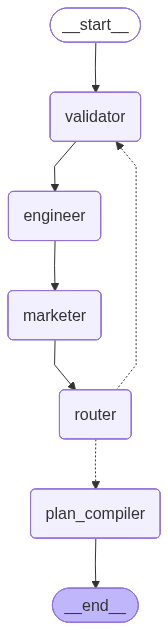

In [3]:
app = build_workflow()

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

## 4. The Founder's Pitch

In [4]:
PITCH = """
I want to build a satellite imagery analytics company. The idea is to use AI to process
satellite images and provide actionable insights for agriculture, urban planning,
and environmental monitoring.

We'd offer an API and dashboard where customers upload coordinates or draw regions
on a map, and we return analyzed imagery with change detection, crop health scores,
deforestation alerts, and urban expansion tracking.

Target customers: agricultural enterprises, government agencies, insurance companies,
and environmental NGOs.

Revenue model: SaaS subscription with tiered pricing based on area coverage and
refresh frequency.
"""

display(Markdown(f"### 📝 Founder's Pitch\n{PITCH}"))

### 📝 Founder's Pitch

I want to build a satellite imagery analytics company. The idea is to use AI to process
satellite images and provide actionable insights for agriculture, urban planning,
and environmental monitoring.

We'd offer an API and dashboard where customers upload coordinates or draw regions
on a map, and we return analyzed imagery with change detection, crop health scores,
deforestation alerts, and urban expansion tracking.

Target customers: agricultural enterprises, government agencies, insurance companies,
and environmental NGOs.

Revenue model: SaaS subscription with tiered pricing based on area coverage and
refresh frequency.


## 5. Run the Multi-Turn Conversation (3 Turns)

Watch all 3 employees debate across 3 turns, then converge into a plan.

In [5]:
turn_labels = {
    "validator": "🔴 STARTUP VALIDATOR (CSO)",
    "engineer": "🔵 SENIOR ENGINEER (CTO)",
    "marketer": "🟢 GROWTH MARKETER (CMO)",
    "plan_compiler": "💡 PLAN COMPILER",
}

results = {}
current_turn = 1

for node_name, output in stream_startup_workflow(PITCH):
    if node_name == "router":
        current_turn += 1
        display(Markdown(f"\n---\n# 🔄 TURN {current_turn} BEGINS\n---\n"))
        continue
    
    if "messages" in output:
        for msg in output["messages"]:
            content = msg.content if hasattr(msg, "content") else msg.get("content", "")
            display(Markdown(content))
            display(Markdown("---"))
    
    results[node_name] = output

print("\n✅ Multi-turn conversation complete!")

🔴 **RUTHLESS CSO (startup-validator) — Turn 1**

# Ruthless CSO Response: Tearing Down the Pitch

### 1. Customer Clarity: Who Specifically Needs This?
- “Agricultural enterprises, government agencies, insurance companies, and environmental NGOs” are *broad categories*. Who EXACTLY is desperate for this solution? Name 3 real people or organizations you’ve talked to. 
- Which *specific problem* is costing these customers money or time? Is crop health scoring really their top pain point? Or is it something else?  
- What’s the dollar value of their problem? If this doesn’t save them a significant amount of money or time, why would they pay for it?

### 2. Lean Canvas Required: Riskiest Assumptions Identified
Here’s where the riskiest assumptions in your pitch lie:
- **Problem:** Are crop health scores, deforestation alerts, etc., their MOST urgent problems? Or are these features speculative?  
- **Customer Segment Fit:** Are these groups already spending money on similar analytics tools? If not, are they even willing to pay for this?  
- **Solution:** You’re assuming AI can deliver actionable insights at a high accuracy rate. Do you have a dataset or prototype proving this?  
- **Revenue Model:** SaaS subscription sounds promising, but how much would they actually pay per month? Have you tested willingness to pay?  
- **Channels:** How will these segments even find your product? You’re pitching multiple industries—how exactly will we reach them without wasting resources?

### 3. Market Validation: Evidence Gap
- Have you conducted ANY customer interviews yet? What did they say? Did someone explicitly say: “I need deforestation alerts via satellite analytics” or “Crop health scoring would save me $X per year”?  
- Who are your competitors? What do they already offer? If this market is saturated, how is your solution differentiated?  
- What’s the TAM (Total Addressable Market)? You’re listing four industries—how big is the actual paying market for satellite imagery analytics?

### 4. Premature Scaling Risks
- You’re pitching an API and dashboard right out of the gate. Did customers tell you they need both? Would it be wiser to validate ONE feature (e.g., crop health scoring) with a manual MVP before investing in tech infrastructure?  
- If AI accuracy isn’t solid yet, building flashy dashboards is wasted effort. Focus on validating the core algorithm first.

### 5. Core Hypothesis: Does Anyone Actually Care?
- Crop health scoring, deforestation alerts, urban expansion tracking—these are hypotheses, not validated needs. Which of these features has the strongest evidence of demand?  
- Do customers even care about “satellite imagery” as a source? Or do they only care about actionable insights? If so, why not start with cheaper data sources before scaling to satellite imagery?

---

**CSO's Open Questions:**  
- Name 3 real people or organizations you’ve talked to in each customer segment. What EXACTLY did they say they need?  
- Which single feature solves the most urgent problem for customers? Validate ONE before pitching a suite of features.  
- What evidence do you have that customers will pay for this? Have you tested pricing?  
- Can we build a manual MVP (no AI, no APIs) to validate demand?  

**CSO's Verdict:** CONDITIONAL GO  
- This idea has potential, but it’s built on vague assumptions. We will not allocate resources until you validate a single feature with actual customer demand. Prepare a Lean Canvas and customer interviews before moving forward.

---

🔵 **ELITE CTO (senior-engineer) — Turn 1**

## CTO Response: Let's Cut Through the Noise

### 1. Ruthless CSO is Right: Narrow the Scope
I agree with the CSO—this pitch is too broad and built on unvalidated assumptions. We need to focus on **one customer segment**, **one pain point**, and **one feature** for the MVP. Right now, we’re trying to do too much, too soon. Let’s pause the API, dashboard, and suite of features until we validate demand.

#### My Approach:
- **Customer Segment:** Pick ONE niche out of the four (e.g., agricultural enterprises). Who exactly are these enterprises? Are we talking about large-scale farms, ag-tech startups, or crop insurance providers?  
- **Pain Point:** Validate the ONE problem costing them the most money. For example, is it crop yield prediction? Pest outbreak detection? Water usage inefficiency?  
- **Feature:** Build the simplest version of **one actionable insight**. Forget change detection, urban expansion, and deforestation. Let’s pick the **most urgent agricultural problem** and solve it with a basic prototype.

### 2. MVP = Manual, Not AI
We don’t need AI or satellite pipelines yet. For the MVP, we can manually process a handful of satellite images and deliver insights to a few test customers.  
- **No AI Until Demand is Proven:** We don’t even know if customers care about “AI-based crop scoring.” Let’s manually analyze 10 satellite images, generate a report, and see if someone pays for it.  
- **Forget the Dashboard:** Email them the results. Dashboards are expensive to build and maintain. Until we know what insights matter to them, UI is a distraction.  

### 3. Avoid Over-Promising Tech
The CMO might be tempted to pitch the API, automated dashboards, and AI pipeline in marketing materials, but we can’t deliver that in 2 weeks. Let’s promise **insights, not tech** for now. The customer doesn’t care if it’s AI or a human in the loop—they just want results.

---

### My Proposed MVP Stack: Bare Minimum to Prove Demand
Here’s how we can build this in the simplest way possible:

#### Step 1: Data Collection
- Use **free satellite imagery** from public sources like Sentinel-2 or Landsat 8. No need for complex integrations yet.  
- Focus on **one niche geography**—e.g., a specific agricultural region where we can find real customers to test with.

#### Step 2: Manual Insights
- Analyze the satellite images manually or with **basic off-the-shelf tools**. For instance:  
  - Crop health: Use NDVI (Normalized Difference Vegetation Index) calculations. Open-source libraries like QGIS or Python’s rasterio can handle this.  
  - Change detection: Basic before-and-after image comparisons.  
- No need for custom AI models yet. Simplicity is key.

#### Step 3: Manual Delivery
- Deliver insights in a PDF or email. Forget APIs and dashboards for now.  
- Example: “Your crops in Region A show a 20% drop in vegetation health compared to last month. Here’s a suggested action plan.”

#### Step 4: Test Willingness to Pay
- Offer this to 3-5 potential customers for a fee. If they balk at paying, we’ve saved ourselves months of engineering effort.  

---

### Responses to CSO Points:
1. **Customer Clarity:** Spot on. The founder needs to name specific organizations or people who’ve said, “This is a burning problem.” If they haven’t, let’s spend a week doing customer interviews before writing a single line of code.  
2. **Lean Canvas:** I’ll help refine the riskiest technical assumptions. For example, can we process open satellite data without heavy infrastructure? Is NDVI enough for actionable insights?  
3. **Evidence Gap:** We’ll validate with a manual MVP. If no one pays for a basic crop health report, there’s no point scaling to AI or dashboards.  
4. **Premature Scaling Risks:** Agreed. API and dashboard are overkill for MVP. We’ll test a single insight first.  

---

### Questions for the CMO:
1. **Go-To-Market Plan:** Can you find 3-5 agricultural enterprises or contacts who are willing to test a crop health report? If not, how are we reaching this niche?  
2. **Messaging:** Let’s pitch “actionable crop health insights” instead of overloading the message with AI, API, and dashboards. Does that resonate better?  
3. **Timeline Alignment:** Can we promise a pilot in 2 weeks? Anything more ambitious is unrealistic at this stage.  

---

**CTO’s Tech Decisions:**
- **Manual MVP over AI:** Analyze satellite images manually using open-source tools like QGIS. No AI until demand is proven.  
- **No API or Dashboard Yet:** Insights delivered via email or PDF. Avoid unnecessary UI/UX overhead for now.  
- **Free Satellite Data:** Use Sentinel-2 or Landsat 8 to avoid costly satellite integrations.  

**CTO’s Build Timeline:**
- **Week 1:** Collect free satellite imagery for one region. Conduct 3-5 customer interviews to validate demand.  
- **Week 2:** Manually process images and deliver 3 test reports. Test willingness to pay.  

If no one pays for this, we pivot or kill the idea before wasting resources. Simple, fast, and focused.

---

🟢 **VIRAL CMO (growth-marketer) — Turn 1**

## 🔥 Viral CMO Response: Making This Sellable

### 1. Emotional Hook: What’s the Story Customers Will Tell?
Neither "AI" nor "satellite imagery" is the hook here. Customers don’t care *how* the insights are generated—they care about the transformation they get. Let’s focus on their problems, in their words:
- **For farmers:** “Am I about to lose my crops, and how do I fix it before it’s too late?”
- **For ag insurers:** “How can I avoid paying out claims for preventable damage?”
- **For NGOs:** “Where is deforestation happening *right now*, so I can act before it’s irreversible?”

This isn’t a tech product—it’s a **crystal ball for their risks**. That’s the hook.

---

### 2. CSO’s Ruthless Validation: My Take
I agree—this pitch is too wide. Here’s how we get laser-focused:
- **Customer Segment:** Let’s target large-scale farmers or agricultural co-ops for MVP. Why? They’re desperate for actionable data to avoid losing revenue. Plus, they’re already spending on crop monitoring tools (competitors = proof of budget).
- **Problem:** “Crops are dying, and we don’t know why until it’s too late.” That’s the pain. Forget deforestation and urban planning for now.
- **Solution:** A **Crop Health Report** delivered directly to farmers’ inboxes, showing what’s wrong and what to do next. Forget APIs or dashboards—we sell peace of mind, not tech fluff.

---

### 3. CTO’s Scope Cuts: Yes, But Let’s Polish the Deliverable
I agree with starting manually and skipping the API and dashboard. But we can’t just dump raw data into someone’s inbox. Farmers don’t want an NDVI chart—they want a **clear, actionable takeaway** written in plain English. Example:
- **Bad Deliverable:** “NDVI values in this area dropped by 20%.”
- **Good Deliverable:** “Your cornfields in Zone A are showing early signs of drought stress. You need to increase irrigation by 15% this week.”

Here’s how we refine your manual MVP:
1. **Language First:** Every report needs to answer three questions: “What’s happening? Why? What should I do?”
2. **Add Visuals:** A simple, color-coded crop health map will resonate more than walls of text. Farmers need to *see the problem* immediately.
3. **Call to Action:** End every report with a concrete recommendation they can act on immediately. Make it impossible for them to ignore.

---

### 4. Pushback: How Are We Reaching These Farmers?
The CSO and CTO are focused on building, but let’s be real—if we don’t get this in front of customers FAST, none of this matters. Here’s the distribution plan we need to align on:
1. **Direct Outreach to Early Adopters:** I’ll identify 10-15 large-scale farmers or ag co-ops in regions with drought risk or crop stress. We email or call them directly with a free pilot offer. (Yes, free—early pilots are about learning, not revenue.)
2. **Partnerships:** Can we partner with ag-tech hardware companies (e.g., irrigation system providers) to bundle this as a value-add for their customers?
3. **Ag Conferences/Communities:** Farmers don’t browse SaaS marketplaces. We need to show up where they are—agriculture expos, forums like AgTalk, or even local co-op meetings.

---

### 5. Messaging Framework: How We Sell This
Here’s the positioning I recommend:
- **Problem:** “Your crops are at risk, and you don’t know it until it’s too late.”
- **Guide:** “We use satellite insights to warn you about crop stress early—before your yields drop.”
- **Transformation:** “Stop guessing. Start saving your crops and your profits.”

**Headline for Landing Page:**  
“Save Your Crops Before It’s Too Late.  
Get Early Warnings for Drought, Disease, and Stress—Delivered to Your Inbox.”

**Tagline:**  
“See the risk. Fix the problem. Save your crops.”

---

### 6. Next Steps and Marketing Plan
I’ll own the messaging and go-to-market testing while the CTO builds the manual MVP. Here’s my timeline:
1. **Week 1 (Parallel to MVP Build):**  
   - Identify 10-15 large-scale farmers or co-ops. Outreach begins.  
   - Create a landing page and outreach email focused on the **Crop Health Report**.  
   - Draft a sample report template with visuals, plain language, and recommendations.  
2. **Week 2:**  
   - Run outreach campaign. Call or email all targets to pitch the free pilot.  
   - Collect feedback on report clarity and willingness to pay.  
   - Test pricing assumptions: “Would you pay $X/month for this?”  
3. **Week 3:**  
   - Refine messaging based on feedback. Start building interest for a paid tier.  

---

**CMO’s Positioning:**  
“This is not about satellite imagery or AI—it’s an early warning system for farmers to save their crops and profits.”

**CMO’s Launch Channels:**  
1. **Direct Outreach (High Impact):** Email or call large-scale farmers and co-ops.  
2. **Landing Page (Moderate Impact):** Capture leads during outreach.  
3. **Partnerships (Moderate Impact):** Work with ag-tech companies to co-sell.  
4. **Ag Communities (Low Impact):** Forums like AgTalk or ag expos for early buzz.  

Let’s stop building in the dark—time to test if farmers *actually* care.

...

---


---
# 🔄 TURN 4 BEGINS
---


💡 **FINAL ACTION PLAN**

# **FINAL STARTUP ACTION PLAN**

---

### 1. **Company Summary (3 sentences max)**  
We are building a satellite imagery analytics company that delivers actionable crop health insights to large-scale farmers, starting with Iowa corn producers. By leveraging free satellite imagery and AI-driven analysis, we identify crop stress early, enabling farmers to prevent yield loss and boost profits. Our initial focus is on validating the problem, customer segment, and willingness to pay through a manual MVP and customer interviews.

---

### 2. **Validated Problem & Customer Segment**  
- **Problem:** Large-scale corn farmers face significant revenue loss from undetected crop stress (e.g., drought, nutrient deficiency, pests) until it’s too late to act. Current solutions are either too expensive, too vague, or not actionable.  
- **Customer Segment:** Large-scale corn farmers in Iowa managing 500+ acres, with a focus on those who are members of co-ops or work closely with ag-extension officers.

---

### 3. **Action Plan Table**

| **Task**                                          | **Owner (CSO/CTO/CMO)** | **Timeline**   | **Priority** | **Dependencies**                                        |
|--------------------------------------------------|-------------------------|----------------|--------------|-------------------------------------------------------|
| Identify 10 Iowa farmers or co-op managers       | CMO                     | Day 3, Week 1  | P0           | Co-op/ag-extension officer connections                |
| Conduct 10 customer discovery interviews         | CMO                     | Day 5, Week 1  | P0           | Identified farmers/co-op managers                     |
| Approve interview script                         | CSO                     | Day 2, Week 1  | P0           | Draft script by CMO                                   |
| Collect Sentinel-2 imagery for Iowa region       | CTO                     | Day 4, Week 1  | P0           | None                                                  |
| Prepare draft Crop Health Report template        | CTO                     | Day 5, Week 1  | P0           | Sentinel-2 imagery                                    |
| Finalize messaging based on interview insights   | CMO                     | Day 1, Week 2  | P0           | Interview findings                                    |
| Deliver 2-3 test Crop Health Reports             | CTO                     | Day 5, Week 2  | P0           | Data processing and collaboration with CMO            |
| Ensure actionable recommendations in reports     | CMO                     | Day 5, Week 2  | P0           | Draft reports from CTO                                |
| Collect feedback on MVP reports                  | CMO                     | Day 7, Week 2  | P0           | Delivered reports to test farmers                    |
| Analyze interview and MVP feedback               | CSO                     | Day 2, Week 3  | P0           | Interview data and MVP feedback                       |
| Validate pricing and willingness-to-pay          | CSO                     | Day 3, Week 3  | P0           | Interview findings                                    |
| Decide go/no-go/pivot based on validation data   | CSO                     | Day 5, Week 3  | P0           | Analysis of all data                                  |
| Research costs for higher-res imagery            | CTO                     | Week 3         | P1           | Feedback indicating resolution issues                 |
| Draft referral/viral growth loop strategy        | CMO                     | Week 3         | P1           | Positive validation                                   |
| Refine Lean Canvas based on findings             | CSO                     | Week 3         | P1           | Validation data                                       |
| Explore pivot options if validation fails        | All                     | Week 3         | P1           | Failed validation of MVP                              |
| Prepare for next phase (pilot rollout or pivot)  | All                     | Week 4         | P1           | Positive or negative go/no-go decision                |

---

### 4. **Week 1 Sprint**

#### **CSO (You):**
1. Approve the customer interview script by **Day 2**.  
2. Begin analyzing competitive landscape and pricing strategies.  
3. Ensure the Lean Canvas is updated with feedback from CMO and CTO.  

#### **CTO:**
1. Collect Sentinel-2 data for Iowa-focused regions by **Day 4**.  
2. Prepare a draft report template with NDVI maps and placeholders for insights by **Day 5**.  

#### **CMO:**
1. Identify 10 target farmers/co-op managers by **Day 3** (complete with warm intro sources).  
2. Conduct 10 farmer interviews by **Day 5**, collecting verbatim feedback on pain points, current solutions, and willingness to pay.  
3. Summarize findings and key quotes by **Day 5** for the team.  

---

### 5. **Key Risks & Mitigations**

1. **Farmer Skepticism:** Farmers may distrust satellite data or see it as another tech gimmick.  
   - *Mitigation:* Use warm intros through trusted co-ops and ag-extension officers. Focus on practical benefits, not technical jargon.  

2. **Resolution Limitations:** Sentinel-2’s 10m resolution may not meet farmers’ expectations for actionable insights.  
   - *Mitigation:* Be upfront about resolution as a broad trend detection tool. Investigate costs for higher-res imagery (e.g., Planet Labs) if feedback indicates it’s critical.  

3. **Unclear Recommendations:** If reports don’t provide clear, actionable advice, farmers won’t see value.  
   - *Mitigation:* Collaborate with agri-experts or extension officers to validate recommendations before delivery.  

4. **Low Willingness to Pay:** Farmers may not see enough value to justify paying for the service.  
   - *Mitigation:* Explicitly test pricing during interviews and MVP delivery. Pivot to a different customer segment (e.g., co-ops, ag-tech companies) if individual farmers aren’t a fit.  

5. **Operational Scalability:** Customization demands from farmers might make scaling costly and inefficient.  
   - *Mitigation:* Test operational feasibility during the MVP phase and pivot if customization overwhelms manual processes.  

---

### 6. **Success Metrics**  
1. **Customer Discovery:** Complete 10 customer interviews by the end of Week 1 with clear data on pain points, current solutions, and pricing expectations.  
2. **MVP Delivery:** Successfully deliver 2-3 actionable Crop Health Reports to test farmers by the end of Week 2.  
3. **Validation Decision:** Make a go/no-go/pivot decision by Day 5 of Week 3, based on validated problem relevance, resolution adequacy, and willingness to pay.

---

This plan puts us on a clear path to validate the idea quickly, with ruthless focus on execution, customer insights, and actionable feedback. Let’s execute.

---


✅ Multi-turn conversation complete!


## 6. 📋 Final Action Plan — Who Does What

The compiled plan with specific tasks, owners, and timelines.

In [6]:
if "plan_compiler" in results and results["plan_compiler"].get("final_plan"):
    display(Markdown("# 💡 FINAL STARTUP ACTION PLAN\n"))
    display(Markdown(results["plan_compiler"]["final_plan"]))
else:
    print("⚠️ No final plan found — check if the workflow completed.")

# 💡 FINAL STARTUP ACTION PLAN


# **FINAL STARTUP ACTION PLAN**

---

### 1. **Company Summary (3 sentences max)**  
We are building a satellite imagery analytics company that delivers actionable crop health insights to large-scale farmers, starting with Iowa corn producers. By leveraging free satellite imagery and AI-driven analysis, we identify crop stress early, enabling farmers to prevent yield loss and boost profits. Our initial focus is on validating the problem, customer segment, and willingness to pay through a manual MVP and customer interviews.

---

### 2. **Validated Problem & Customer Segment**  
- **Problem:** Large-scale corn farmers face significant revenue loss from undetected crop stress (e.g., drought, nutrient deficiency, pests) until it’s too late to act. Current solutions are either too expensive, too vague, or not actionable.  
- **Customer Segment:** Large-scale corn farmers in Iowa managing 500+ acres, with a focus on those who are members of co-ops or work closely with ag-extension officers.

---

### 3. **Action Plan Table**

| **Task**                                          | **Owner (CSO/CTO/CMO)** | **Timeline**   | **Priority** | **Dependencies**                                        |
|--------------------------------------------------|-------------------------|----------------|--------------|-------------------------------------------------------|
| Identify 10 Iowa farmers or co-op managers       | CMO                     | Day 3, Week 1  | P0           | Co-op/ag-extension officer connections                |
| Conduct 10 customer discovery interviews         | CMO                     | Day 5, Week 1  | P0           | Identified farmers/co-op managers                     |
| Approve interview script                         | CSO                     | Day 2, Week 1  | P0           | Draft script by CMO                                   |
| Collect Sentinel-2 imagery for Iowa region       | CTO                     | Day 4, Week 1  | P0           | None                                                  |
| Prepare draft Crop Health Report template        | CTO                     | Day 5, Week 1  | P0           | Sentinel-2 imagery                                    |
| Finalize messaging based on interview insights   | CMO                     | Day 1, Week 2  | P0           | Interview findings                                    |
| Deliver 2-3 test Crop Health Reports             | CTO                     | Day 5, Week 2  | P0           | Data processing and collaboration with CMO            |
| Ensure actionable recommendations in reports     | CMO                     | Day 5, Week 2  | P0           | Draft reports from CTO                                |
| Collect feedback on MVP reports                  | CMO                     | Day 7, Week 2  | P0           | Delivered reports to test farmers                    |
| Analyze interview and MVP feedback               | CSO                     | Day 2, Week 3  | P0           | Interview data and MVP feedback                       |
| Validate pricing and willingness-to-pay          | CSO                     | Day 3, Week 3  | P0           | Interview findings                                    |
| Decide go/no-go/pivot based on validation data   | CSO                     | Day 5, Week 3  | P0           | Analysis of all data                                  |
| Research costs for higher-res imagery            | CTO                     | Week 3         | P1           | Feedback indicating resolution issues                 |
| Draft referral/viral growth loop strategy        | CMO                     | Week 3         | P1           | Positive validation                                   |
| Refine Lean Canvas based on findings             | CSO                     | Week 3         | P1           | Validation data                                       |
| Explore pivot options if validation fails        | All                     | Week 3         | P1           | Failed validation of MVP                              |
| Prepare for next phase (pilot rollout or pivot)  | All                     | Week 4         | P1           | Positive or negative go/no-go decision                |

---

### 4. **Week 1 Sprint**

#### **CSO (You):**
1. Approve the customer interview script by **Day 2**.  
2. Begin analyzing competitive landscape and pricing strategies.  
3. Ensure the Lean Canvas is updated with feedback from CMO and CTO.  

#### **CTO:**
1. Collect Sentinel-2 data for Iowa-focused regions by **Day 4**.  
2. Prepare a draft report template with NDVI maps and placeholders for insights by **Day 5**.  

#### **CMO:**
1. Identify 10 target farmers/co-op managers by **Day 3** (complete with warm intro sources).  
2. Conduct 10 farmer interviews by **Day 5**, collecting verbatim feedback on pain points, current solutions, and willingness to pay.  
3. Summarize findings and key quotes by **Day 5** for the team.  

---

### 5. **Key Risks & Mitigations**

1. **Farmer Skepticism:** Farmers may distrust satellite data or see it as another tech gimmick.  
   - *Mitigation:* Use warm intros through trusted co-ops and ag-extension officers. Focus on practical benefits, not technical jargon.  

2. **Resolution Limitations:** Sentinel-2’s 10m resolution may not meet farmers’ expectations for actionable insights.  
   - *Mitigation:* Be upfront about resolution as a broad trend detection tool. Investigate costs for higher-res imagery (e.g., Planet Labs) if feedback indicates it’s critical.  

3. **Unclear Recommendations:** If reports don’t provide clear, actionable advice, farmers won’t see value.  
   - *Mitigation:* Collaborate with agri-experts or extension officers to validate recommendations before delivery.  

4. **Low Willingness to Pay:** Farmers may not see enough value to justify paying for the service.  
   - *Mitigation:* Explicitly test pricing during interviews and MVP delivery. Pivot to a different customer segment (e.g., co-ops, ag-tech companies) if individual farmers aren’t a fit.  

5. **Operational Scalability:** Customization demands from farmers might make scaling costly and inefficient.  
   - *Mitigation:* Test operational feasibility during the MVP phase and pivot if customization overwhelms manual processes.  

---

### 6. **Success Metrics**  
1. **Customer Discovery:** Complete 10 customer interviews by the end of Week 1 with clear data on pain points, current solutions, and pricing expectations.  
2. **MVP Delivery:** Successfully deliver 2-3 actionable Crop Health Reports to test farmers by the end of Week 2.  
3. **Validation Decision:** Make a go/no-go/pivot decision by Day 5 of Week 3, based on validated problem relevance, resolution adequacy, and willingness to pay.

---

This plan puts us on a clear path to validate the idea quickly, with ruthless focus on execution, customer insights, and actionable feedback. Let’s execute.

## 7. 👥 Team Responsibility Summary

Quick reference: what each employee owns based on their skill definition and conversation.

In [7]:
all_skills = [
    (VALIDATOR_SKILL, results.get("validator", {}).get("validator_output", "")),
    (ENGINEER_SKILL, results.get("engineer", {}).get("engineer_output", "")),
    (MARKETER_SKILL, results.get("marketer", {}).get("marketer_output", "")),
]

summary_md = "# 👥 Team Responsibility Matrix\n\n"

for skill, last_output in all_skills:
    summary_md += f"## {skill['emoji']} {skill['title']} ({skill['name']})\n\n"
    summary_md += "**Core Responsibilities:**\n"
    for resp in skill['plan_responsibilities']:
        summary_md += f"- ✅ {resp}\n"
    summary_md += f"\n**Final Position (Turn 3):**\n"
    excerpt = last_output[:800] + "..." if len(last_output) > 800 else last_output
    summary_md += f"> {excerpt}\n\n"
    summary_md += "---\n\n"

display(Markdown(summary_md))

# 👥 Team Responsibility Matrix

## 🔴 Ruthless CSO (startup-validator)

**Core Responsibilities:**
- ✅ Customer discovery interviews (minimum 10)
- ✅ Lean Canvas iteration and validation
- ✅ Pricing strategy and willingness-to-pay research
- ✅ Competitive landscape analysis
- ✅ Unit economics modeling

**Final Position (Turn 3):**
> # Ruthless CSO Response: Final Validation and Convergence

I’ve reviewed the CTO’s technical plan and the CMO’s distribution strategy. Both are narrowing focus, which I appreciate, but there are still gaps in precision, execution, and validation that we need to address. Let’s break this down and converge.

---

## 1. **CTO’s Tech Plan: Oversights in Precision and Deliverability**
Your manual MVP plan is lean and pragmatic, but it’s assuming a lot about customer expectations and data quality without any real-world feedback. Here’s what I see:

### Strengths:
- **Manual MVP:** Starting without AI or dashboards is the right approach. Using free satellite imagery and open-source tools is exactly the kind of lean thinking we need right now.  
- **Simple Deliverables:** A PDF or email is suffici...

---

## 🔵 Elite CTO (senior-engineer)

**Core Responsibilities:**
- ✅ MVP architecture and tech stack setup
- ✅ Core API development (satellite image ingestion + analysis)
- ✅ Dashboard/UI prototype
- ✅ Infrastructure provisioning and CI/CD
- ✅ Data pipeline for satellite imagery processing

**Final Position (Turn 3):**
> ## Elite CTO Response: Final Convergence and Ownership

Alright team, I’ve read through everyone’s feedback, and I’m locking in on the simplest, most actionable plan. I’ll address your points directly, finalize the MVP scope, and clearly define what I’ll own to move us forward.

---

### 1. **CSO’s Concerns and Questions**
#### **Manual MVP Feasibility**
Yes, I can deliver 2-3 manually processed reports in Week 2. The NDVI analysis is straightforward using QGIS and Python tools like rasterio. This is a manageable workload, and I’ll produce actionable insights tailored to our test farmers. However, I’ll need input from the CMO on how to frame these insights in **plain, actionable language** that resonates.

#### **Resolution Risk**
You’re right—10m resolution could be a sticking point. I’ll...

---

## 🟢 Viral CMO (growth-marketer)

**Core Responsibilities:**
- ✅ Landing page copy and design direction
- ✅ Launch tweet/LinkedIn thread and social content calendar
- ✅ Cold outreach email templates for first 10 customers
- ✅ Content marketing strategy (Month 1 blog/video plan)
- ✅ Referral/viral growth loop design

**Final Position (Turn 3):**
> ## 🔥 Viral CMO Final Response: Convergence and Execution

Alright team, it’s time to execute. I’ve digested the CSO’s ruthless validation plan and the CTO’s refined MVP scope. We’re aligned on the need for a razor-sharp focus, customer-first messaging, and ruthless validation of both the problem and willingness to pay before building anything more.

Here’s my final take, addressing your concerns, locking in my ownership, and aligning all moving parts into an action plan we can execute immediately.

---

### 1. **CSO’s Ruthless Challenges**
#### "Unvalidated Messaging" and Farmer Skepticism  
You’re absolutely right: our messaging cannot rest on assumptions. Farmers don’t care about “insights” or satellite jargon—they care about avoiding revenue loss. I’ll ensure **interviews and outreach**...

---



## 8. Try Your Own Pitch

In [8]:
# Uncomment and modify:
#
# MY_PITCH = "I want to build an AI-powered legal document review tool for small law firms..."
#
# for node_name, output in stream_startup_workflow(MY_PITCH):
#     if node_name == "router":
#         continue
#     if "messages" in output:
#         for msg in output["messages"]:
#             content = msg.content if hasattr(msg, "content") else msg.get("content", "")
#             display(Markdown(content))
#             display(Markdown("---"))